In [315]:
import anndata as ad
from statsmodels.stats.multitest import multipletests 
import matplotlib
# import palantir
import scanpy as sc
from utils import *
from first_part import *
from adjustText import adjust_text
atac_input_file_name = "../../Cellformer/cellformer_PD/adata_deconvolution_PD_2024_trained_all_filtered_Jan6_lognorm_0.2.h5ad"
outdir = "./outdir/"

In [316]:
##Load data
adata = sc.read_h5ad(atac_input_file_name)
adata = prepareData(adata)
adata

/Users/eloiseberson/code/PD-epigenomic-analysis/src/utils.py:104: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["condition2"] = adata.obs["condition"].replace({"LRRK2-PD-":"LRRK2", "LRRK2-PD+":"LRRK2"}).values


AnnData object with n_obs × n_vars = 2358 × 42352
    obs: 'celltype', 'replicate', 'brain_region', 'condition', 'Sex', 'batch', 'PatientID', 'Unnamed: 0', 'Sample_id', 'Name', 'OldName', 'NewName', 'HarmonizedName', 'Bam', 'Contrast', 'Type', 'Group', 'Region', 'RegionMod', 'PatientIDMod', 'TypeMod', 'Cohort', 'TissueCenter', 'TypeGroup', 'xxx.TechRep', 'Batch', 'xxx.Sample', 'xxx.Library', 'xxx.BioRep', 'xxx.TechRep.1', 'Pool', 'xxx.race', 'Gender', 'age at death', 'PMI', 'Mutation', 'MutationType', 'xxx.last_mmse_test_score', 'ApoE', 'xxx.last_mmse_test_date', 'xxx.motor_updrs_score_on', 'xxx.motor_updrs_score_off', 'xxx.motor_updrs_score_months_prior_to_death', 'xxx.Control', 'xxx.AD', 'xxx.PD', 'xxx.DLB', 'xxx.VAD', 'xxx.PSP', 'xxx.HS', 'xxx.DLDH', 'xxx.MND', 'xxx.CBD', 'xxx.PICKS', 'xxx.HD', 'xxx.MSA', 'xxx.ARG', 'xxx.CWMR', 'xxx.dementia_nos', 'xxx.MS', 'xxx.CAA', 'xxx.MCI', 'xxx.LBS', 'xxx.BRAIN_ABNORMAL', 'xxx.ACUTE_INFARCTS', 'xxx.PlaqueF', 'xxx.PlaqueT', 'xxx.PlaqueP', 'xxx.

In [163]:
adata.obs.groupby(["condition","Sex"]).PatientID.nunique()

condition  Sex   
CTRL       Female     5
           Male      10
GBA1-PD+   Female     6
           Male       9
LRRK2-PD+  Female     1
           Male       2
SPOR       Female     3
           Male      12
Name: PatientID, dtype: int64

In [164]:
adata.obs['MutationType'].unique().tolist()

[nan,
 'N370S/N370S',
 'E326K',
 'T369M, V447E',
 'T369M',
 'L1114L',
 'N370S',
 'T369M, C342',
 'S196P',
 'H255Q',
 'L444P',
 'G2019S']

In [165]:
adata.obs["ApoE4"].unique()

array(['E4-', 'E4+'], dtype=object)

In [166]:
adata.obs[["condition", "PatientID",'age at death']].drop_duplicates().groupby("condition")['age at death'].std()

condition
CTRL         4.611580
GBA1-PD+     5.853774
LRRK2-PD+    4.358899
SPOR         5.671199
Name: age at death, dtype: float64

In [ ]:
#DE SPOR & GBA1 PD+
method = 'pydeseq2_sex_adjusted_no_refit_refined'
condition = "condition"
peaks_df = differential_expression(adata[adata.obs.condition.isin(["SPOR", "GBA1-PD+","LRRK2-PD+"])], 0,
                    method, corr_=["Sex"], columns=condition)
peaks_df
peaks_df.to_pickle("./res_DE_%s_%s.pickle"%(method,condition))

In [317]:
#Fixed adjusting pvalue problem and annotated significant CAR
method = 'pydeseq2_sex_adjusted_no_refit_refined'
condition = "condition"
res_DE_file_name = "./res_DE_%s_%s.pickle"%(method,condition)

outname = "de_corr"
res_DE = pd.read_pickle(res_DE_file_name)
res_DE.comparison.unique()


res_DE = compute_multitesting(res_DE) 
res_DE = filter_sig(res_DE,logFC = 0, pvalue=0.05)

#plot_DE(res_DE,outdir,outname)
# res_DE = res_DE[res_DE.comparison == "SPOR$GBA1"]


outname = "DE_%s_%s"%(method,condition)

90it [00:44,  2.03it/s]


In [318]:
res_DE

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,index,nearestGeneChip,nearestGene,peakType,...,names,-log10(pvals),-log10(qvals),ranks,significant,downreg,type_reg,comparison,br,ct
chr1_999876_1000376,942.882189,-0.048359,0.884246,-0.054690,0.956385,0.999719,chr1_999876_1000376,HES4,HES4,Promoter,...,chr1_999876_1000376,0.019367,0.000122,-0.000006,False,False,not significant,SPOR$GBA1-PD+,CAUD,AST
chr1_1158074_1158574,2670.059302,0.030981,0.064609,0.479517,0.631571,0.999719,chr1_1158074_1158574,MIR200B,MIR200B,Distal,...,chr1_1158074_1158574,0.199578,0.000122,0.000004,False,False,not significant,SPOR$GBA1-PD+,CAUD,AST
chr1_1298766_1299266,2559.752973,0.070011,0.100838,0.694288,0.487502,0.999719,chr1_1298766_1299266,ACAP3,MIR6726,Exonic,...,chr1_1298766_1299266,0.312024,0.000122,0.000009,False,False,not significant,SPOR$GBA1-PD+,CAUD,AST
chr1_1357803_1358303,1550.104594,0.078913,0.244054,0.323344,0.746435,0.999719,chr1_1357803_1358303,MXRA8,MXRA8,Intronic,...,chr1_1357803_1358303,0.127008,0.000122,0.000010,False,False,not significant,SPOR$GBA1-PD+,CAUD,AST
chr1_1360395_1360895,1693.367800,0.014888,0.127752,0.116539,0.907225,0.999719,chr1_1360395_1360895,MXRA8,MXRA8,Intronic,...,chr1_1360395_1360895,0.042285,0.000122,0.000002,False,False,not significant,SPOR$GBA1-PD+,CAUD,AST
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chrX_141969569_141970069,1226.372735,0.313949,0.165053,1.902114,0.057156,0.527359,chrX_141969569_141970069,LOC105373345,MAGEC1,Distal,...,chrX_141969569_141970069,1.242936,0.403970,0.126826,False,False,not significant,SPOR$All,SUNI,OLD
chrX_150291081_150291581,2359.912456,0.036492,0.045085,0.809402,0.418284,0.880156,chrX_150291081_150291581,MIR2114,MIR2114,Distal,...,chrX_150291081_150291581,0.378529,0.117467,0.004287,False,False,not significant,SPOR$All,SUNI,OLD
chrX_150465368_150465868,1990.332139,0.211749,0.077476,2.733103,0.006274,0.271425,chrX_150465368_150465868,MAMLD1,MTM1,Intronic,...,chrX_150465368_150465868,2.202450,0.717013,0.151827,False,False,not significant,SPOR$All,SUNI,OLD
chrX_153478652_153479152,1285.819236,0.211502,0.136311,1.551616,0.120754,0.655115,chrX_153478652_153479152,ECMXP,BGN,Intronic,...,chrX_153478652_153479152,0.918098,0.293120,0.061995,False,False,not significant,SPOR$All,SUNI,OLD


Index(['CAUD', 'HIPP', 'MDFG', 'PTMN', 'SMTG', 'SUNI'], dtype='object', name='br')
Index(['CAUD', 'HIPP', 'MDFG', 'PTMN', 'SMTG', 'SUNI'], dtype='object', name='br')
Index(['CAUD', 'HIPP', 'MDFG', 'PTMN', 'SMTG', 'SUNI'], dtype='object', name='br')
Index(['CAUD', 'HIPP', 'MDFG', 'PTMN', 'SMTG', 'SUNI'], dtype='object', name='br')
Index(['CAUD', 'HIPP', 'MDFG', 'PTMN', 'SMTG', 'SUNI'], dtype='object', name='br')
Index(['CAUD', 'HIPP', 'MDFG', 'PTMN', 'SMTG', 'SUNI'], dtype='object', name='br')


/Users/eloiseberson/code/PD-epigenomic-analysis/src/first_part.py:669: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


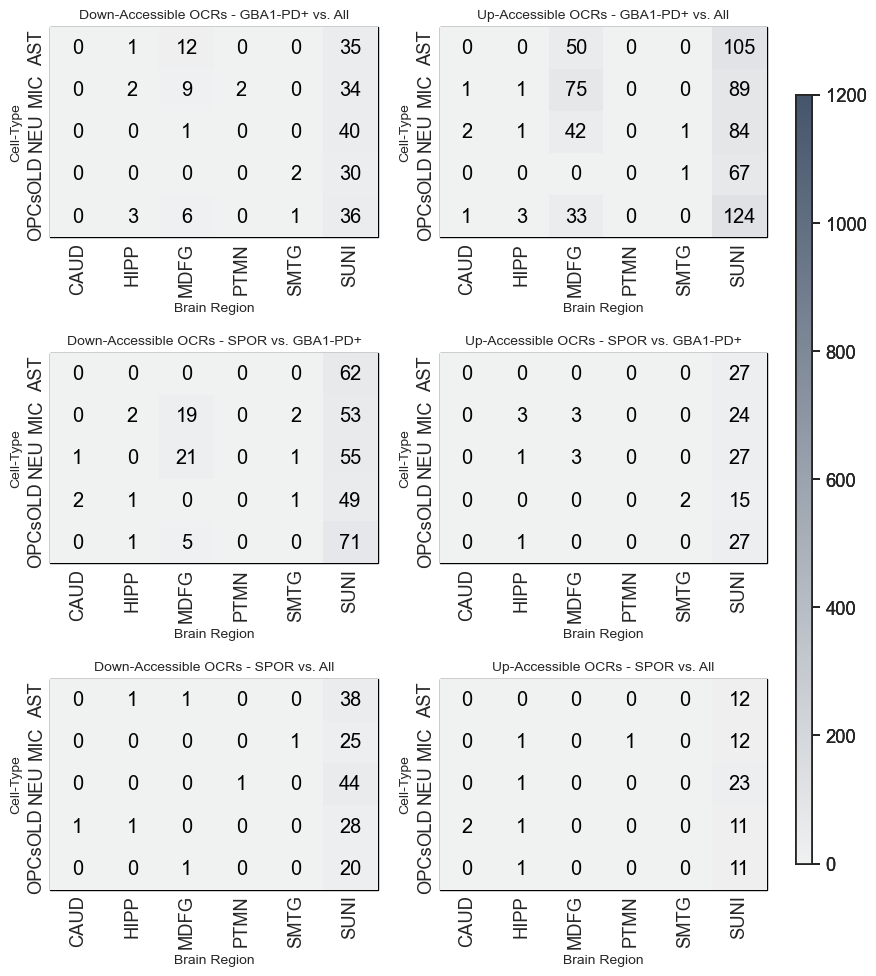

In [319]:
plot_DE_number(res_DE,outdir,outname, cmap=cmap)#,lf_key='log2FoldChange')


In [320]:
res_DE.comparison.unique()

array(['SPOR$GBA1-PD+', 'GBA1-PD+$All', 'SPOR$All'], dtype=object)

/var/folders/yn/qvpxfrdd5870gxhq9hf9jvc40000gq/T/ipykernel_89071/2958098966.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  topplot["comparison"] = topplot["comparison"].str.replace("-PD+","")


Index(['CAUD', 'HIPP', 'MDFG', 'PTMN', 'SMTG', 'SUNI'], dtype='object', name='br')
Index(['CAUD', 'HIPP', 'MDFG', 'PTMN', 'SMTG', 'SUNI'], dtype='object', name='br')


/Users/eloiseberson/code/PD-epigenomic-analysis/src/utils.py:416: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


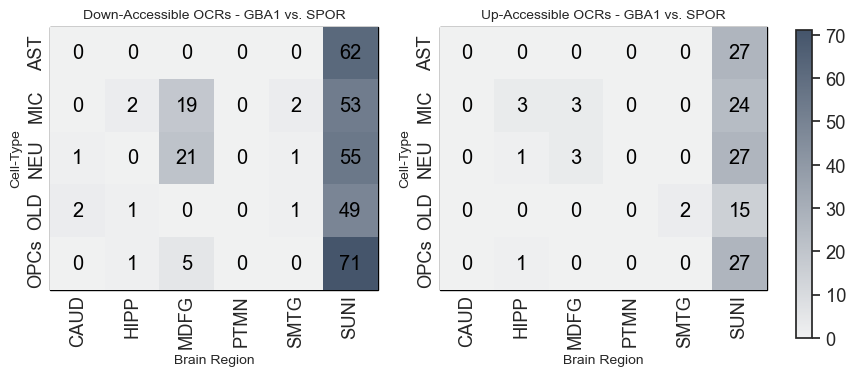

In [321]:
topplot = res_DE[res_DE.comparison=='SPOR$GBA1-PD+']
topplot["comparison"] = topplot["comparison"].str.replace("-PD+","")
plot_DE_number_one(topplot,
                       outdir,outname,lf_key='log2FoldChange', 
                       cmap=cmap)

In [173]:
count = res_DE.loc[res_DE.significant==True,["comparison","br","ct"]].groupby(["br","ct","comparison"]).size().reset_index() #count()["log2FoldChange"].reset_index()

count = count.set_index(["br","ct","comparison"])
# all_possibilities = [(br,ct,downreg,comparison)
#                       for (br,ct,downreg,comparison) in product(res_DE["br"].unique(),res_DE["ct"].unique(),res_DE["downreg"].unique(),res_DE["comparison"].unique()) ]

# count = count.set_index(["br","ct","comparison"])
all_possibilities = [(br,ct,comparison)
                      for (br,ct,comparison) in product(res_DE["br"].unique(),res_DE["ct"].unique(),res_DE["comparison"].unique()) ]
    
for pos in all_possibilities:
        if pos not in count.index:
            count.loc[pos] = 0
    
count = count.reset_index()
# count["downreg"] = count["downreg"].replace({False:"Up regulated",True:"Down regulated"}).astype(str)

# count = count[(count.br=="SUNI") & (count.comparison.isin(["SPOR$GBA1-PD+", "SPOR$All" ,"GBA1-PD+$All"]))].drop("br", axis=1)
count = count[(count.br.isin(["SMTG","SUNI"]))]#.drop("br", axis=1)

df = pd.pivot_table(count, index=["br","comparison"], columns="ct", values=0)
print(df)
df["group"] = [it[0] for it in df.index.tolist()]
df = df.set_index("group")
df = df
df

ct                    AST    MIC    NEU   OLD   OPCs
br   comparison                                     
SMTG GBA1-PD+$All     0.0    0.0    1.0   3.0    1.0
     SPOR$All         0.0    1.0    0.0   0.0    0.0
     SPOR$GBA1-PD+    0.0    2.0    1.0   3.0    0.0
SUNI GBA1-PD+$All   140.0  123.0  124.0  97.0  160.0
     SPOR$All        50.0   37.0   67.0  39.0   31.0
     SPOR$GBA1-PD+   89.0   77.0   82.0  64.0   98.0


ct,AST,MIC,NEU,OLD,OPCs
group,,,,,
SMTG,0.0,0.0,1.0,3.0,1.0
SMTG,0.0,1.0,0.0,0.0,0.0
SMTG,0.0,2.0,1.0,3.0,0.0
SUNI,140.0,123.0,124.0,97.0,160.0
SUNI,50.0,37.0,67.0,39.0,31.0
SUNI,89.0,77.0,82.0,64.0,98.0


In [174]:
res_DE.loc[res_DE.significant==True,["comparison","br","ct"]].groupby(["br","ct","comparison"]).size()

br    ct    comparison   
CAUD  MIC   GBA1-PD+$All       1
      NEU   GBA1-PD+$All       2
            SPOR$GBA1-PD+      1
      OLD   SPOR$All           3
            SPOR$GBA1-PD+      2
      OPCs  GBA1-PD+$All       1
HIPP  AST   GBA1-PD+$All       1
            SPOR$All           1
      MIC   GBA1-PD+$All       3
            SPOR$All           1
            SPOR$GBA1-PD+      5
      NEU   GBA1-PD+$All       1
            SPOR$All           1
            SPOR$GBA1-PD+      1
      OLD   SPOR$All           2
            SPOR$GBA1-PD+      1
      OPCs  GBA1-PD+$All       6
            SPOR$All           1
            SPOR$GBA1-PD+      2
MDFG  AST   GBA1-PD+$All      62
            SPOR$All           1
      MIC   GBA1-PD+$All      84
            SPOR$GBA1-PD+     22
      NEU   GBA1-PD+$All      43
            SPOR$GBA1-PD+     24
      OPCs  GBA1-PD+$All      39
            SPOR$All           1
            SPOR$GBA1-PD+      5
PTMN  MIC   GBA1-PD+$All       2
            SPOR$

In [175]:
REGION = "SUNI"#"SUNI"
COMP=["SPOR$GBA1-PD+", "SPOR$All" ,"GBA1-PD+$All"]

count = res_DE[(res_DE.br==REGION) & (res_DE.comparison.isin(COMP))]

count = count.loc[count.significant==True,[ "comparison","br","ct"]].groupby(["br","ct","comparison"]).size().reset_index()
# count["downreg"] = count["downreg"].replace({False:"Up regulated",True:"Down regulated"})
count = count.set_index(["br","ct","comparison"])

all_possibilities = [(br,ct,comparison)
                      for (br,ct,comparison) in product([REGION],res_DE["ct"].unique(),[COMP]) ]
# print(all_possibilities)
to_add = [it for it in all_possibilities if it not in count.index.tolist()]
reverse = [it for it in  count.index.tolist() if it not in all_possibilities ]

# for pos in to_add:
#             count.loc[pos] = 0
# print(count)
count = count.reset_index()


count = count[(count.br==REGION) & (count.comparison.isin(COMP))].drop("br", axis=1)
print(count)
df = pd.pivot_table(count, index=["comparison"], columns="ct", values=0)
#df["group"] = [it[0]+"|"+it[1] for it in df.index.tolist()]
#df = df.set_index("group")
df

      ct     comparison    0
0    AST   GBA1-PD+$All  140
1    AST       SPOR$All   50
2    AST  SPOR$GBA1-PD+   89
3    MIC   GBA1-PD+$All  123
4    MIC       SPOR$All   37
5    MIC  SPOR$GBA1-PD+   77
6    NEU   GBA1-PD+$All  124
7    NEU       SPOR$All   67
8    NEU  SPOR$GBA1-PD+   82
9    OLD   GBA1-PD+$All   97
10   OLD       SPOR$All   39
11   OLD  SPOR$GBA1-PD+   64
12  OPCs   GBA1-PD+$All  160
13  OPCs       SPOR$All   31
14  OPCs  SPOR$GBA1-PD+   98


ct,AST,MIC,NEU,OLD,OPCs
comparison,,,,,
GBA1-PD+$All,140.0,123.0,124.0,97.0,160.0
SPOR$All,50.0,37.0,67.0,39.0,31.0
SPOR$GBA1-PD+,89.0,77.0,82.0,64.0,98.0


In [176]:
count = res_DE.loc[res_DE.significant==True,["comparison","br","ct"]].groupby(["br","ct","comparison"]).size().reset_index() #count()["log2FoldChange"].reset_index()

count = count.set_index(["br","ct","comparison"])
# all_possibilities = [(br,ct,downreg,comparison)
#                       for (br,ct,downreg,comparison) in product(res_DE["br"].unique(),res_DE["ct"].unique(),res_DE["downreg"].unique(),res_DE["comparison"].unique()) ]

# count = count.set_index(["br","ct","comparison"])
all_possibilities = [(br,ct,comparison)
                      for (br,ct,comparison) in product(res_DE["br"].unique(),res_DE["ct"].unique(),res_DE["comparison"].unique()) ]
    
for pos in all_possibilities:
        if pos not in count.index:
            count.loc[pos] = 0
    
count = count.reset_index()
# count["downreg"] = count["downreg"].replace({False:"Up regulated",True:"Down regulated"}).astype(str)

# count = count[(count.br=="SUNI") & (count.comparison.isin(["SPOR$GBA1-PD+", "SPOR$All" ,"GBA1-PD+$All"]))].drop("br", axis=1)
count = count#[(count.br.isin(["HIPP"]))]#.drop("br", axis=1)

df = pd.pivot_table(count, index=["br","comparison"], columns="ct", values=0)
print(df)
df["group"] = [it[0] for it in df.index.tolist()]
df = df.set_index("group")
df = df
df

ct                    AST    MIC    NEU   OLD   OPCs
br   comparison                                     
CAUD GBA1-PD+$All     0.0    1.0    2.0   0.0    1.0
     SPOR$All         0.0    0.0    0.0   3.0    0.0
     SPOR$GBA1-PD+    0.0    0.0    1.0   2.0    0.0
HIPP GBA1-PD+$All     1.0    3.0    1.0   0.0    6.0
     SPOR$All         1.0    1.0    1.0   2.0    1.0
     SPOR$GBA1-PD+    0.0    5.0    1.0   1.0    2.0
MDFG GBA1-PD+$All    62.0   84.0   43.0   0.0   39.0
     SPOR$All         1.0    0.0    0.0   0.0    1.0
     SPOR$GBA1-PD+    0.0   22.0   24.0   0.0    5.0
PTMN GBA1-PD+$All     0.0    2.0    0.0   0.0    0.0
     SPOR$All         0.0    1.0    1.0   0.0    0.0
     SPOR$GBA1-PD+    0.0    0.0    0.0   0.0    0.0
SMTG GBA1-PD+$All     0.0    0.0    1.0   3.0    1.0
     SPOR$All         0.0    1.0    0.0   0.0    0.0
     SPOR$GBA1-PD+    0.0    2.0    1.0   3.0    0.0
SUNI GBA1-PD+$All   140.0  123.0  124.0  97.0  160.0
     SPOR$All        50.0   37.0   67.0  39.0 

ct,AST,MIC,NEU,OLD,OPCs
group,,,,,
CAUD,0.0,1.0,2.0,0.0,1.0
CAUD,0.0,0.0,0.0,3.0,0.0
CAUD,0.0,0.0,1.0,2.0,0.0
HIPP,1.0,3.0,1.0,0.0,6.0
HIPP,1.0,1.0,1.0,2.0,1.0
HIPP,0.0,5.0,1.0,1.0,2.0
MDFG,62.0,84.0,43.0,0.0,39.0
MDFG,1.0,0.0,0.0,0.0,1.0
MDFG,0.0,22.0,24.0,0.0,5.0


In [177]:
# plot_DE_number(res_DE,outdir,outname)#,lf_key='log2FoldChange')

Text(0, 0.0, 'CAUD')
Text(0, 1.0, 'HIPP')
Text(0, 2.0, 'MDFG')
Text(0, 3.0, 'SMTG')
Text(0, 4.0, 'SUNI')


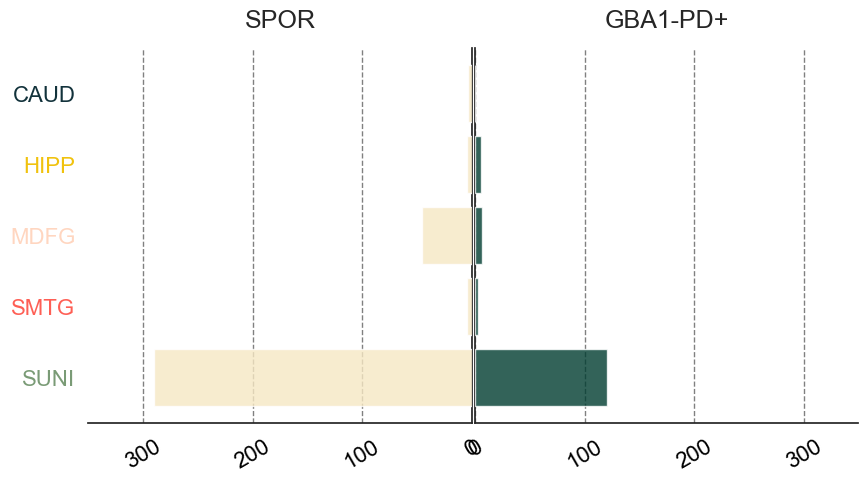

Text(0, 0.0, 'CAUD')
Text(0, 1.0, 'HIPP')
Text(0, 2.0, 'MDFG')
Text(0, 3.0, 'SMTG')
Text(0, 4.0, 'SUNI')


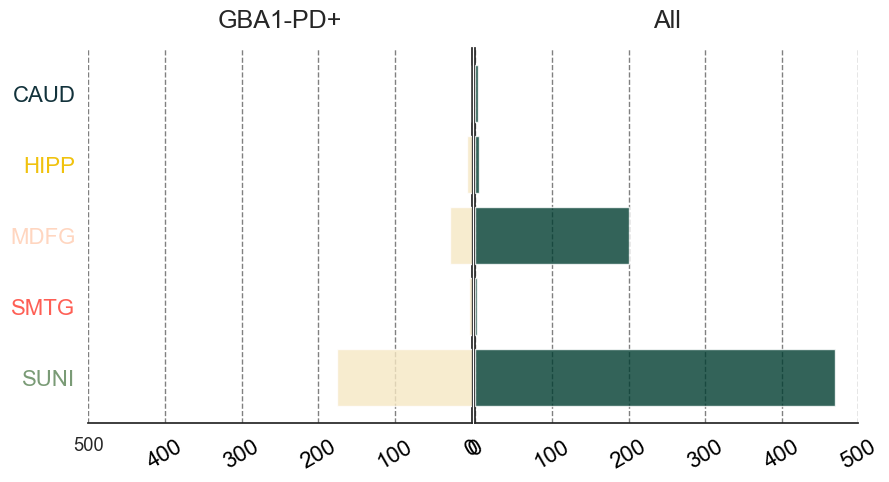

Text(0, 0.0, 'CAUD')
Text(0, 1.0, 'HIPP')
Text(0, 2.0, 'MDFG')
Text(0, 3.0, 'SMTG')
Text(0, 4.0, 'SUNI')


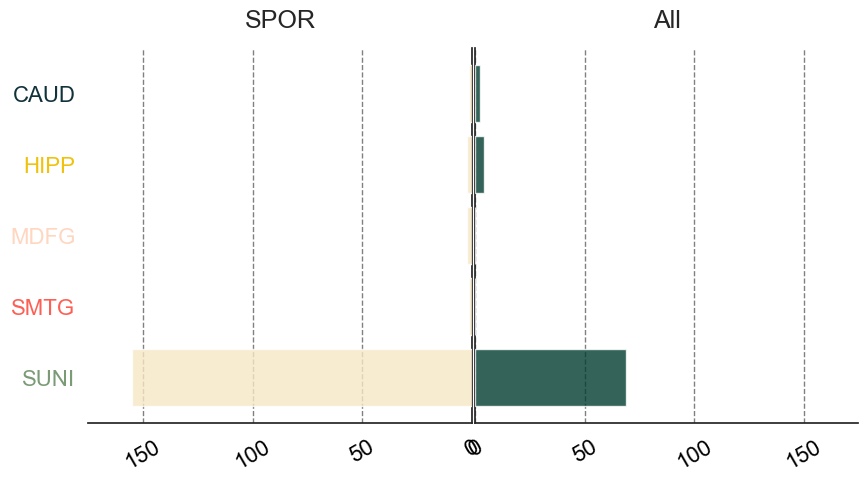

In [322]:
comp = "SPOR$GBA1/PD+/AD+"
comp = "GBA1/PD+/AD-$GBA1/PD+/AD+"
comp = "SPOR$GBA1-PD+"

region = ["CAUD","HIPP","MDFG",  "SMTG", "SUNI"]#"PTMN",

if condition=="ApoE4":
    region = ["CAUD","MDFG", "PTMN", "SMTG", "SUNI"]
for comp in res_DE.comparison.unique():
    cond1, cond2 = comp.split("$")
    de = res_DE[(res_DE.type_reg!="not significant") & (res_DE.comparison ==comp ) ]
    
    
    to_plot = pd.DataFrame(index=de.br.unique().tolist())
    to_plot =to_plot.loc[region,:]
    up = de[de["type_reg"]=="up"]
    up = pd.DataFrame(up.groupby("br").size(),#/len(up),
                      columns=["up"])
    to_plot = to_plot.join(up).fillna(0)
    up = de[de["type_reg"]=="down"]
    up = pd.DataFrame(up.groupby("br").size(),#/len(up),
                      columns=["down"])
    to_plot = to_plot.join(up).fillna(0)
    
    # to_plot = to_plot.sort_values("up", ascending=False)
    palette= {"up": "#4dac26", "down":"#d01c8b"}
    palette= {"down": "#F6E8C3", "up":"#003C30"}
    fig, axes = plt.subplots(figsize=(10,5), ncols=2, sharey=True)
    fig.tight_layout()
    
    brain_regions = to_plot.index.tolist()
    
    left1 = len(to_plot) * [0]
    left2 = len(to_plot) * [0]
    index = to_plot.index#.map('|'.join)
    # for idx, name in enumerate(brain_regions):
    axes[0].barh(index, to_plot["down"], left = left1, color=palette["down"],zorder=10, align="center", alpha=0.8)#, fill=False)
    axes[1].barh(index, to_plot["up"], left = left2, color=palette["up"],zorder=10, align="center", alpha=0.8)#, fill=False)
        # left1 = left1 + down[name]
        # left2 = left2 + up[name]
    
    axes[0].set_title(cond1, fontsize=18, pad=15)
    axes[1].set_title(cond2, fontsize=18, pad=15)
    
                
    # If you have positive numbers and want to invert the x-axis of the left plot
    axes[0].invert_xaxis() 
    
    # To show data from highest to lowest
    plt.gca().invert_yaxis()
        
    axes[0].set(yticks=brain_regions, yticklabels=brain_regions)
    axes[0].yaxis.tick_left()
    axes[0].tick_params(axis='y', colors='white') # tick color
    
    axes[1].spines['right'].set_visible(False)
    axes[0].spines['left'].set_visible(False)
    axes[0].spines['top'].set_visible(False)
    axes[1].spines['top'].set_visible(False)
    
    
    font_color = 'black'
    tmp = []
    for label in (axes[0].get_xticklabels()):
        label.set(fontsize=16, color=font_color, rotation=30)
    for label in (axes[1].get_xticklabels()):
        label.set(fontsize=16, color=font_color, rotation=30)
    for label in (axes[0].get_yticklabels()):
        print(label)
        txt = label.get_text()#.split("|")[1]
    
        cond = label.get_text()#.split("|")[0]
        tmp.append(cond)
        label.set(color=COLORS_CT[cond], label=str(txt), fontsize=16 )
    
    # labels = [item.get_text() for item in axes[0].get_yticklabels()]
    
    axes[1].yaxis.set_ticks_position('none') 
    # adjust limits and draw grid lines
    # plt.ylim(-0.5, ax.get_yticks()[-1] + 0.5)
    axes[0].set_axisbelow(True)
    axes[0].xaxis.grid(color='gray', linestyle='dashed')
    axes[1].set_axisbelow(True)
    axes[1].xaxis.grid(color='gray', linestyle='dashed')
    
    max_x = max(max(axes[0].get_xticks()),max(axes[1].get_xticks()))
    axes[0].set_xlim(max_x,0)
    axes[1].set_xlim(0,max_x)
    plt.subplots_adjust(wspace=0.01, top=0.85, bottom=0.1, left=0.18, right=0.95)
    # plt.suptitle("Porportion of cell type-specific DAR", fontsize=18)
    # leg1 = plt.legend(brain_regions, bbox_to_anchor=([0.99, 1, 0, 0]), ncol=4, frameon=False)
    # ll = []
    # for it in list(set(tmp)):
    #     blue_line = lines.Line2D([], [], color=color_cond[it], 
    #                                         marker="o",
    #                                         linestyle='None',
    #                                         markersize=8, label=it)
    #     ll.append(blue_line)
    # leg2 = plt.legend(handles=ll, bbox_to_anchor=(1.5, 0.25))
    
    # axes[1].add_artist(leg1)
    
    plt.savefig("./outdir/DE_OCR__%s"%comp.replace("/","-") + ".svg", bbox_inches="tight")
    plt.show()

Text(0, 0, 'AST')
Text(0, 1, 'MIC')
Text(0, 2, 'NEU')
Text(0, 3, 'OLD')
Text(0, 4, 'OPCs')


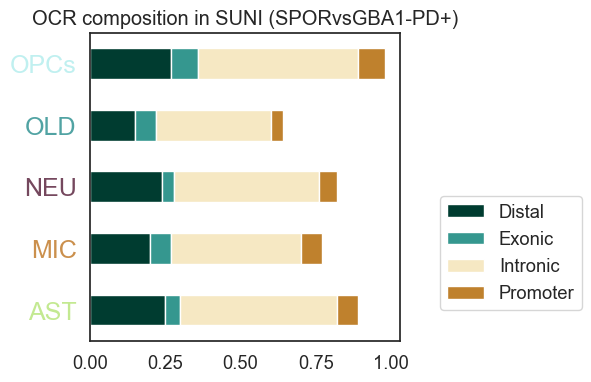

In [323]:
de = res_DE[res_DE.type_reg!="not significant"]


de.comparison.unique()

comp = "SPOR$GBA1-PD+"

# comp = "E4+$E4-"
br="SUNI"
de = de[(de.br ==br)&(de.comparison==comp)]
ff = de.groupby(["ct", "peakType"]).size().unstack()#/de.groupby(["ct", "peakType"]).size().unstack().sum(1).values[:,np.newaxis]
ff /=100.
ax = ff.plot(kind='barh', stacked=True, color=['#003C30', "#35978F", "#F6E8C3", "#BF812D"])

for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    
    x, y = p.get_xy() 
   # ax.annotate(f'{int(height)}%', (x + width/2, y + height*0.5), ha='center')
plt.title("OCR composition in %s (%s)"%(br,comp.replace("$", "vs")))
plt.ylabel("celltype")
for label in (ax.get_yticklabels()):
    print(label)
    txt = label.get_text()#.split("|")[1]

    cond = label.get_text()#.split("|")[0]
    label.set(color=COLORS_CT[cond], label=str(txt), fontsize=18)
ax.set_ylabel("")
ax.legend(bbox_to_anchor=(1.1,0.5))
plt.savefig("./outdir/DE_ocr_spor_gba1_peak_de_composition_%s_%s.svg"%(comp,br), bbox_inches="tight")

In [329]:
res_DE[(res_DE.padj<=0.05) &(res_DE.comparison==comp)].groupby("br").size()/len(res_DE[(res_DE.padj<=0.05) &(res_DE.comparison==comp)])

br
CAUD    0.0075
HIPP    0.0225
MDFG    0.0775
SMTG    0.0150
SUNI    0.8775
dtype: float64

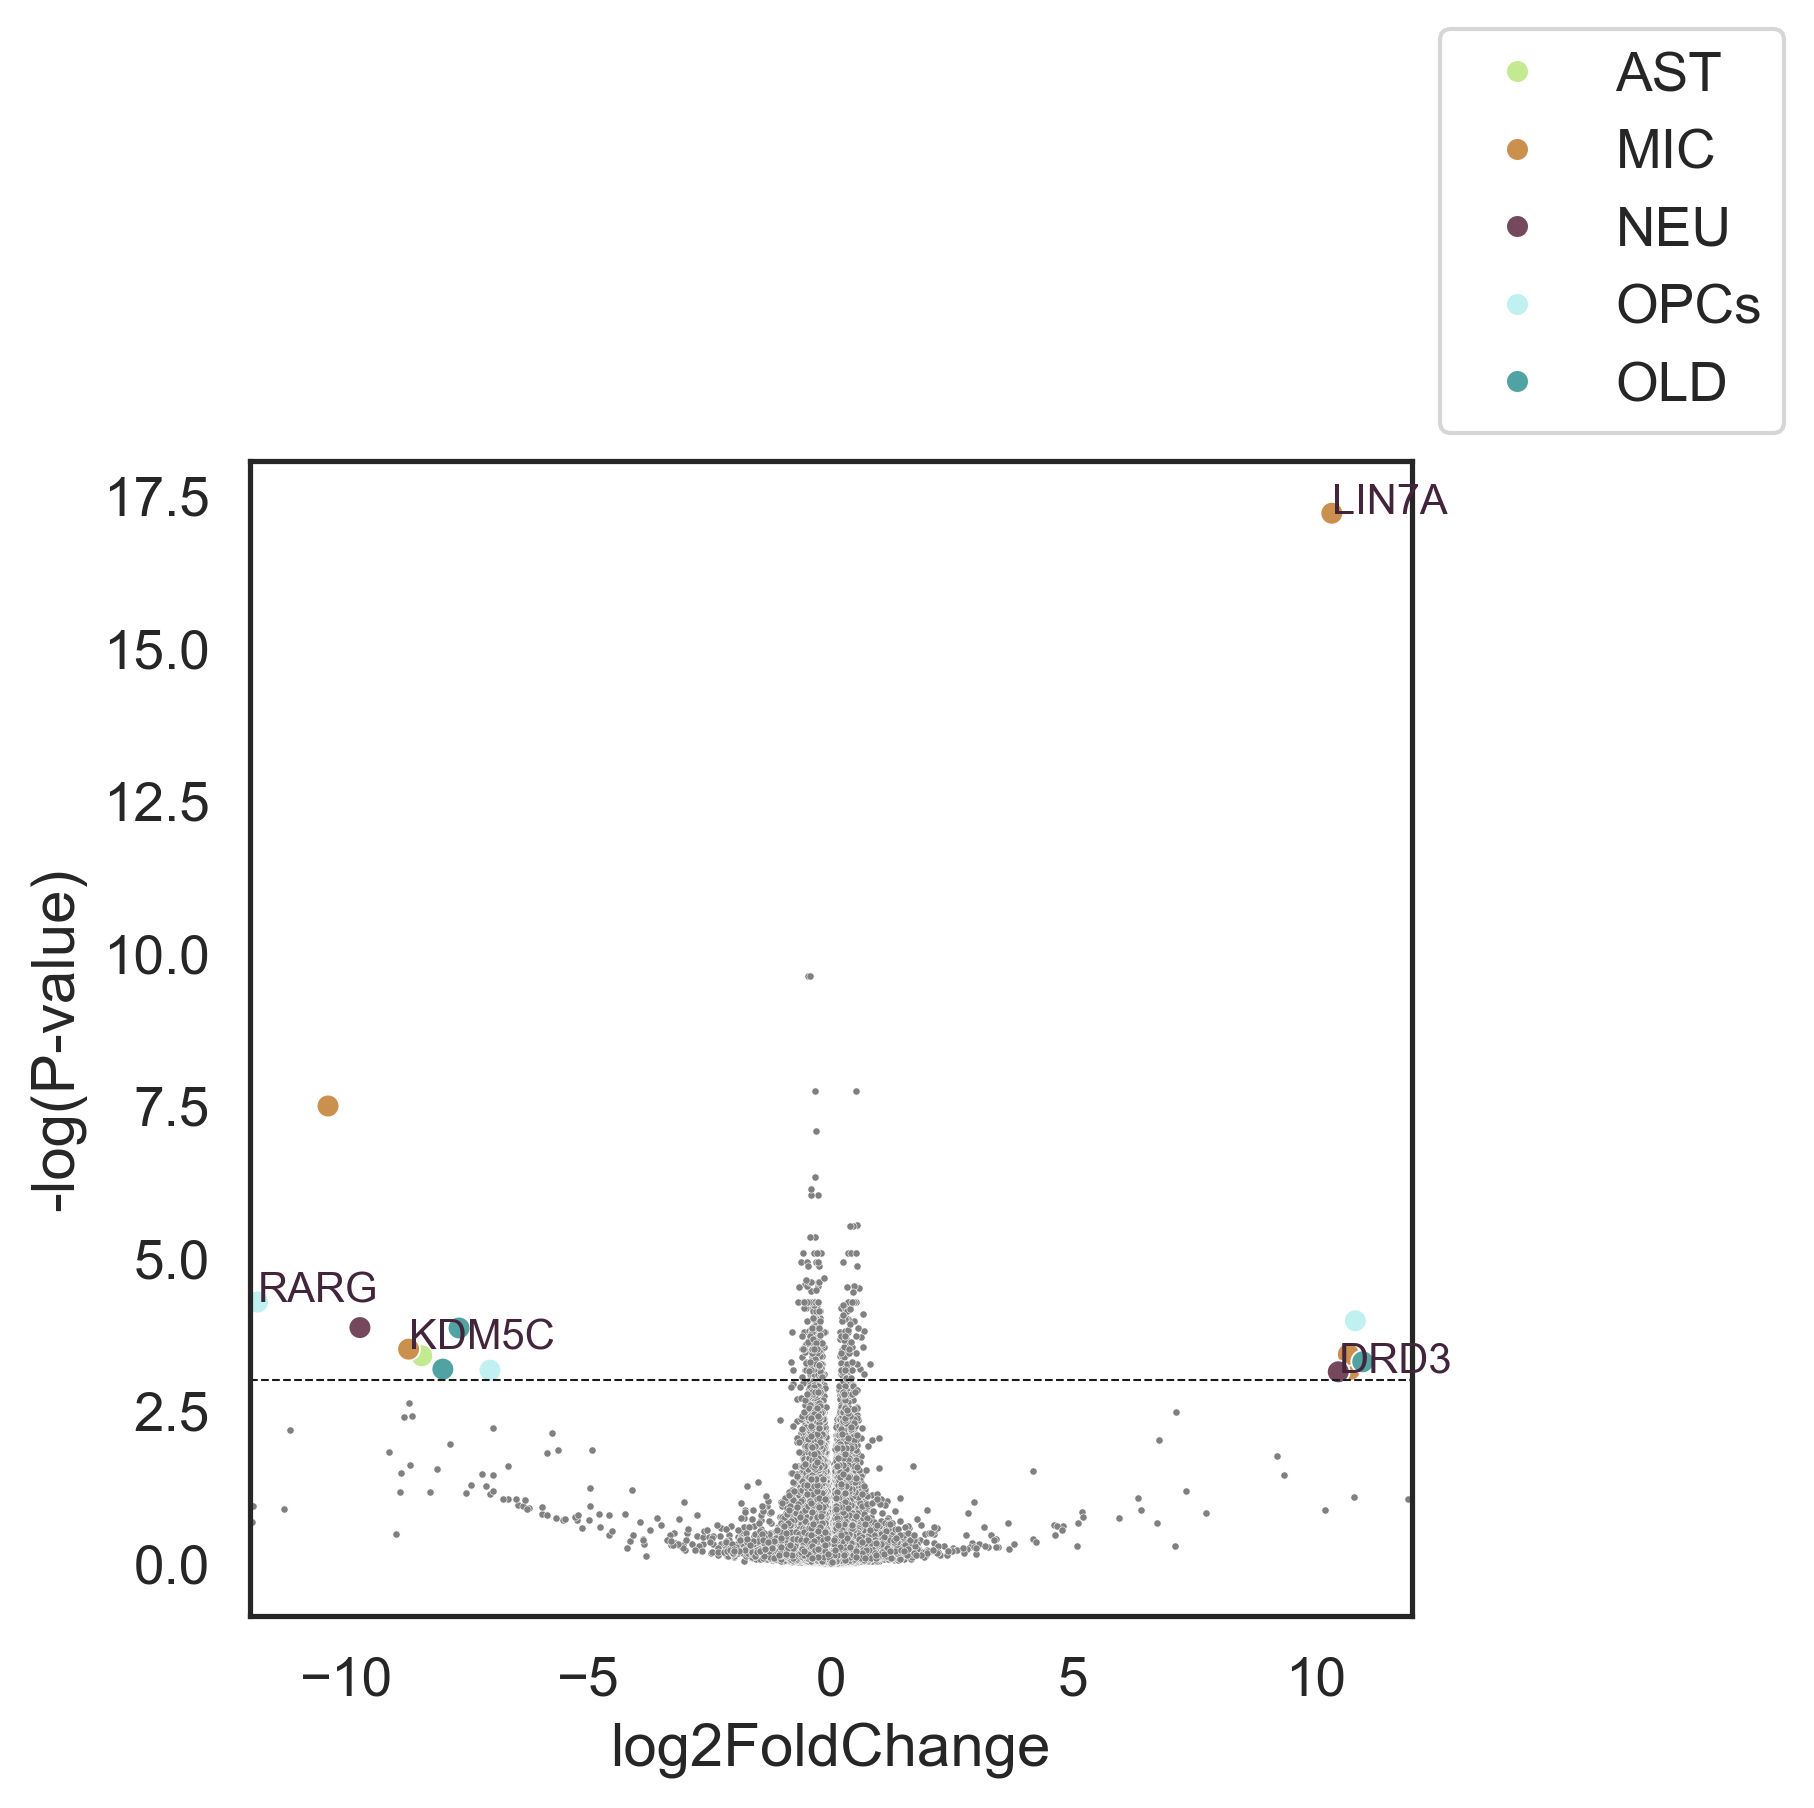

In [281]:
pal = {"3' UTR":"#b18fcf","5' UTR":"#b18fcf","Promoter":"#42253b", "Intron":"#ffa552","Exon":"#82c0cc","Distal Intergenic":"#82d173",  'Downstream (<=300bp)':"#ababab"}

comp = "SPOR$GBA1-PD+"

br="SUNI"
ct = "OPCs"

res_DE["-log(P-value)"] = -np.log(res_DE["padj"])
# res_DE["annot"] = res_DE["annotation"].str.split(" \(", expand=True)[0]

toplot = res_DE[((res_DE.br==br) #&(res_DE.ct==ct)
                &(res_DE.comparison==comp))]

fig, ax = plt.subplots(figsize=(5,5))
x="log2FoldChange"
y="-log(P-value)"
sns.scatterplot(data = toplot[(toplot.padj>0.05) | (np.abs(toplot.log2FoldChange)<1)], x=x, y=y, color="gray", s=3)
sns.scatterplot(data = toplot[(toplot.padj<=0.05) & (np.abs(toplot.log2FoldChange)>=1)], x=x, y=y, color="gray", s=30, 
                hue='ct', palette=COLORS_CT)# pal)
ax.axhline(y=-np.log(0.05), c="k", linestyle="--", linewidth=0.5)
# ax.axvline(x=-0.2, c="k", linestyle="--", linewidth=0.5)
# ax.axvline(x=0.2, c="k", linestyle="--", linewidth=0.5)
ax.legend(bbox_to_anchor=(1,1))

texts = []
for i, it in enumerate(toplot[(toplot.padj<=0.05)&(np.abs(toplot.log2FoldChange)>1)].iterrows()):
    if it[1]['shortAnnotChip']=="Promoter":
        text = plt.text(it[1][x], it[1][y], it[1]["nearestGeneChip"], fontsize=10, color=pal[it[1]['shortAnnotChip']])
        texts.append(text)

# Adjust text to avoid overlap
# adjust_text(texts, arrowprops=dict(arrowstyle="->", color='black'))
ax.set_xlim(-12,12)
plt.savefig("outdir/volcano_deconvoluted_DE_gba_spor_%s_%s.svg"%(br,ct))

In [330]:
res_DE[(res_DE.ct=="NEU") &( res_DE.padj<0.05) &(res_DE.shortAnnotChip == "Promoter") & (res_DE.br=="SUNI")]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,index,nearestGeneChip,nearestGene,peakType,...,names,-log10(pvals),-log10(qvals),ranks,significant,downreg,type_reg,comparison,br,ct
chr1_29323697_29324197,1114.857890,-0.338052,0.088785,-3.807538,0.000140,0.048444,chr1_29323697_29324197,PTPRU,LINC01756,Intronic,...,chr1_29323697_29324197,3.852765,1.419008,-0.479698,True,True,down,SPOR$GBA1-PD+,SUNI,NEU
chr3_46700678_46701178,1639.287950,-0.315732,0.075370,-4.189067,0.000028,0.022284,chr3_46700678_46701178,TMIE,TMIE,Promoter,...,chr3_46700678_46701178,4.552681,1.760454,-0.555832,True,True,down,SPOR$GBA1-PD+,SUNI,NEU
chr3_111957211_111957711,2066.441249,0.260868,0.066748,3.908241,0.000093,0.041678,chr3_111957211_111957711,PHLDB2,ABHD10,Intronic,...,chr3_111957211_111957711,4.031654,1.490427,0.388805,True,False,up,SPOR$GBA1-PD+,SUNI,NEU
chr3_114177979_114178479,35.361148,10.477937,2.724400,3.845961,0.000120,0.043358,chr3_114177979_114178479,DRD3,DRD3,Intronic,...,chr3_114177979_114178479,3.920527,NaN,NaN,False,False,not significant,SPOR$GBA1-PD+,SUNI,NEU
chr3_136197835_136198335,1099.028529,0.357547,0.082870,4.314552,0.000016,0.018168,chr3_136197835_136198335,MSL2,MSL2,Promoter,...,chr3_136197835_136198335,4.796079,1.856924,0.663938,True,False,up,SPOR$GBA1-PD+,SUNI,NEU
chr6_44270883_44271383,1288.075579,-0.326499,0.081802,-3.991355,0.000066,0.035858,chr6_44270883_44271383,TMEM151B,TMEM151B,Intronic,...,chr6_44270883_44271383,4.182455,1.552165,-0.506781,True,True,down,SPOR$GBA1-PD+,SUNI,NEU
chr7_44065324_44065824,2021.699156,-0.251787,0.063990,-3.934766,0.000083,0.039091,chr7_44065324_44065824,PGAM2,PGAM2,Promoter,...,chr7_44065324_44065824,4.079470,1.518470,-0.382330,True,True,down,SPOR$GBA1-PD+,SUNI,NEU
chr7_153886406_153886906,1602.307856,-0.249830,0.053771,-4.646212,0.000003,0.009919,chr7_153886406_153886906,DPP6,DPP6,Promoter,...,chr7_153886406_153886906,5.470973,2.140965,-0.534878,True,True,down,SPOR$GBA1-PD+,SUNI,NEU
chr9_133702300_133702800,996.333752,-0.658139,0.143674,-4.580768,0.000005,0.010873,chr9_133702300_133702800,SARDH,SARDH,Intronic,...,chr9_133702300_133702800,5.334165,2.101067,-1.382795,True,True,down,SPOR$GBA1-PD+,SUNI,NEU
chr9_136721180_136721680,1142.419452,-0.385814,0.096795,-3.985905,0.000067,0.035858,chr9_136721180_136721680,DIPK1B,SNORA17B,Exonic,...,chr9_136721180_136721680,4.172479,1.552165,-0.598847,True,True,down,SPOR$GBA1-PD+,SUNI,NEU


In [283]:
import gseapy as gp

comp = "SPOR$GBA1-PD+"
br="SUNI"
ct = "NEU"
all_ = []
# for ct in res_DE.ct.unique():
if True:
    toplot = res_DE[(res_DE.br==br)&(res_DE.ct==ct)&(res_DE.comparison==comp) ]
                    # & (res_DE["shortAnnotChip"].isin(['Promoter', 'Distal Intergenic',
                    #                                   "3' UTR", 'Intron', 'Exon',
                    #                                   "5' UTR"]))]
    
    gene_list = toplot.set_index("nearestGeneChip")[["log2FoldChange"]].sort_values("log2FoldChange",ascending=False)
    adata.var.index = adata.var.index.astype(str)
    adata.obs.index = adata.obs.index.astype(str)
    bg = adata[:,adata.var["shortAnnotChip"].isin(['Promoter', 'Distal Intergenic',
                                                   "3' UTR", 'Intron', 'Exon', 
                                                   "5' UTR"])].var["nearestGeneChip"].astype(str).unique().tolist()
    bg = adata.var["nearestGeneChip"].astype(str).unique().tolist()

    enr = gp.prerank(rnk=gene_list, # or "./tests/data/gene_list.txt",
                     background=bg,
                     permutation=1000,
                      min_size=2,
                     pheno_pos = "SPOR",
                    pheno_neg = "GBA1",
                     gene_sets=['KEGG_2021_Human'],#
                     # gene_sets=["WikiPathways_2024_Human"],
                     # gene_sets=["Reactome_Pathways_2024"],
                     # gene_sets=['GO_Biological_Process_2023','GO_Cellular_Component_2023','GO_Molecular_Function_2023'],
                     organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                    )
    enr.res2d.sort_values("FDR q-val")
    gg = enr.res2d
    gg["ct"] = ct
    all_.append(gg)
all_ = pd.concat(all_)
all_

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,ct
0,prerank,KEGG_2021_Human__Dopaminergic synapse,0.73465,2.736845,0.0,0.0,0.0,17/68,5.94%,DRD3;GRIA4;GRIA2;PRKCB;PLCB4;PPP2R2D;GSK3B;GNA...,NEU
1,prerank,KEGG_2021_Human__Amino sugar and nucleotide su...,-0.971476,-2.676797,0.0,0.516372,0.201,1/18,0.01%,FPGT,NEU
2,prerank,KEGG_2021_Human__Neuroactive ligand-receptor i...,0.650123,2.650175,0.0,0.001419,0.002,40/140,8.85%,DRD3;GRIA4;CCKBR;BDKRB2;GRIA2;ADRA2A;ADRB1;GRM...,NEU
3,prerank,KEGG_2021_Human__Fructose and mannose metabolism,-0.972383,-2.459127,0.001961,0.296305,0.223,1/13,0.01%,FPGT,NEU
4,prerank,KEGG_2021_Human__Regulation of lipolysis in ad...,-0.710903,-2.181566,0.00969,0.29748,0.373,1/30,0.03%,ADCY4,NEU
...,...,...,...,...,...,...,...,...,...,...,...
311,prerank,KEGG_2021_Human__Synthesis and degradation of ...,-0.32976,-0.599639,0.932632,0.985632,1.0,1/4,9.59%,BDH1,NEU
312,prerank,KEGG_2021_Human__Maturity onset diabetes of th...,-0.243328,-0.582222,0.935484,0.984856,1.0,3/11,19.11%,MNX1;INS;MAFA,NEU
313,prerank,KEGG_2021_Human__Galactose metabolism,0.219975,0.536381,0.967677,0.983389,1.0,3/11,19.74%,G6PC2;GLB1;HK2,NEU
314,prerank,"KEGG_2021_Human__Neomycin, kanamycin and genta...",-0.271034,-0.531975,0.959759,0.993439,1.0,3/5,37.93%,HK1;HK3;GCK,NEU


In [284]:
all_["Number of genes"] = all_["Tag %"].str.split("/", expand=True)[0].astype(int)
all_ =all_[all_["Number of genes"]>1]
all_.sort_values("FDR q-val",ascending=True)[:30]

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,ct,Number of genes
0,prerank,KEGG_2021_Human__Dopaminergic synapse,0.73465,2.736845,0.0,0.0,0.0,17/68,5.94%,DRD3;GRIA4;GRIA2;PRKCB;PLCB4;PPP2R2D;GSK3B;GNA...,NEU,17
2,prerank,KEGG_2021_Human__Neuroactive ligand-receptor i...,0.650123,2.650175,0.0,0.001419,0.002,40/140,8.85%,DRD3;GRIA4;CCKBR;BDKRB2;GRIA2;ADRA2A;ADRB1;GRM...,NEU,40
49,prerank,"KEGG_2021_Human__Growth hormone synthesis, sec...",-0.483887,-1.704348,0.019573,0.090248,0.805,6/59,6.87%,ADCY4;SSTR3;CRK;ADCY1;MAPK3;MAP2K2,NEU,6
45,prerank,KEGG_2021_Human__Cushing syndrome,-0.468867,-1.724359,0.03351,0.091134,0.776,2/76,1.55%,ADCY4;WNT9B,NEU,2
48,prerank,KEGG_2021_Human__Melanogenesis,-0.491814,-1.70773,0.024299,0.092476,0.799,2/53,1.55%,ADCY4;WNT9B,NEU,2
58,prerank,KEGG_2021_Human__Chemical carcinogenesis,-0.449217,-1.636514,0.039216,0.096593,0.901,8/86,7.41%,ADCY4;MIR29C;PAQR5;ADCY1;MAPK3;CCND3;MAP2K2;ARRB1,NEU,8
43,prerank,KEGG_2021_Human__Relaxin signaling pathway,-0.494623,-1.727047,0.028986,0.097651,0.774,2/60,0.79%,ADCY4;NFKBIA,NEU,2
64,prerank,KEGG_2021_Human__Chemokine signaling pathway,-0.446678,-1.606381,0.037702,0.102488,0.938,11/81,8.26%,ADCY4;NFKBIA;CCL2;CCR3;CCR4;CRK;ADCY1;MAPK3;PI...,NEU,11
71,prerank,KEGG_2021_Human__RIG-I-like receptor signaling...,-0.5453,-1.581718,0.031423,0.109216,0.957,5/21,4.45%,TRAF2;NFKBIA;NLRX1;PIN1;TRAF3,NEU,5
36,prerank,KEGG_2021_Human__Human cytomegalovirus infection,-0.468626,-1.765307,0.033275,0.109339,0.709,12/98,7.05%,ADCY4;TRAF2;NFKBIA;CCL2;IL6R;CCR3;CRK;ADCY1;TN...,NEU,12


In [334]:
listtt = all_["Lead_genes"][0].split(";")
res_DE[((res_DE.ct=="NEU") &( res_DE.padj<0.05) 
&(res_DE.shortAnnotChip == "Promoter") & (res_DE.br=="SUNI")
        &(res_DE["nearestGeneChip"].astype(str).isin(listtt)))]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,index,nearestGeneChip,nearestGene,peakType,...,names,-log10(pvals),-log10(qvals),ranks,significant,downreg,type_reg,comparison,br,ct
chr3_114177979_114178479,35.361148,10.477937,2.724400,3.845961,0.000120,0.043358,chr3_114177979_114178479,DRD3,DRD3,Intronic,...,chr3_114177979_114178479,3.920527,NaN,NaN,False,False,not significant,SPOR$GBA1-PD+,SUNI,NEU
chr12_2640645_2641145,1213.448143,0.310730,0.080021,3.883083,0.000103,0.036138,chr12_2640645_2641145,CACNA1C,CACNA1C-AS2,Intronic,...,chr12_2640645_2641145,3.986571,1.534414,0.476788,True,False,up,GBA1-PD+$All,SUNI,NEU


In [285]:
res_DE["shortAnnotChip"].unique()

['Promoter', 'Distal Intergenic', '3' UTR', 'Intron', 'Exon', '5' UTR', 'Downstream (<=300bp)']
Categories (7, object): ['3' UTR', '5' UTR', 'Distal Intergenic', 'Downstream (<=300bp)', 'Exon', 'Intron', 'Promoter']

In [251]:
# import gseapy as gp

# comp = "SPOR$GBA1-PD+"
# br="SUNI"
# ct = "MIC"

# toplot = res_DE[((res_DE.br==br)&(res_DE.ct==ct)&(res_DE.comparison==comp)
#                 &(np.abs(res_DE.log2FoldChange)>=0)
#                  # &(res_DE.shortAnnotChip.isin(['Promoter', 'Distal Intergenic', "3' UTR", 'Intron', 'Exon', "5' UTR"]))
#                  &(res_DE.padj<=0.05))]

# gene_list = toplot["nearestGeneChip"].astype(str).unique().tolist()
# print(len(gene_list))
# adata.var.index = adata.var.index.astype(str)
# adata.obs.index = adata.obs.index.astype(str)
# bg = adata.var["nearestGeneChip"].astype(str).unique().tolist()
# # bg = adata[:,adata.var["shortAnnotChip"].isin(['Promoter', 'Distal Intergenic', "3' UTR", 'Intron', 'Exon', "5' UTR"])].var["nearestGeneChip"].astype(str).unique().tolist()

# enr = gp.enrichr(gene_list, # or "./tests/data/gene_list.txt",
#                  background=bg,
#                   # min_size=2,
#         #          permutation=5000,
#         #          pheno_pos = "SPOR",
#         # pheno_neg = "GBA1",
#                  # gene_sets=['KEGG_2021_Human'],# "Reactome_Pathways_2024", "WikiPathways_2024_Human"],#
#                  # gene_sets=["Reactome_Pathways_2024"],
#                  cutoff=0.05,
#                  gene_sets=['GO_Biological_Process_2023','GO_Cellular_Component_2023','GO_Molecular_Function_2023'],
#                  # organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
#                 )
# enr.res2d[:20]

71


,Gene_set,Term,P-value,Adjusted P-value,Old P-value,Old adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Molecular_Function_2023,G Protein-Coupled Receptor Activity (GO:0004930),0.004157,0.142883,0,0,6.587065,36.116496,GABBR2;ADGRB3;LGR6;ADGRL2
1,GO_Molecular_Function_2023,3'-5' RNA Helicase Activity (GO:0034458),0.004919,0.142883,0,0,inf,inf,YTHDC2
2,GO_Molecular_Function_2023,Phosphotyrosine Residue Binding (GO:0001784),0.008891,0.142883,0,0,15.389157,72.679415,BCAR3;SH3BP2
3,GO_Molecular_Function_2023,G-quadruplex RNA Binding (GO:0002151),0.009815,0.142883,0,0,205.157143,948.622809,DHX30
4,GO_Molecular_Function_2023,Protein Phosphorylated Amino Acid Binding (GO:...,0.012092,0.142883,0,0,12.980072,57.309597,BCAR3;SH3BP2
5,GO_Molecular_Function_2023,SH3 Domain Binding (GO:0017124),0.013494,0.142883,0,0,12.214834,52.591102,SH3BP2;ADAM9
6,GO_Molecular_Function_2023,GTPase Regulator Activity (GO:0030695),0.013632,0.142883,0,0,3.768872,16.188584,TBC1D1;ADGRB3;MCF2L;ARHGEF3;TBC1D22A
7,GO_Molecular_Function_2023,"Oxidoreductase Activity, Acting On Paired Dono...",0.014686,0.142883,0,0,102.571429,432.937939,FADS3
8,GO_Molecular_Function_2023,Sodium Channel Inhibitor Activity (GO:0019871),0.019534,0.142883,0,0,68.376190,269.100288,SCN3B
9,GO_Molecular_Function_2023,Histone H3K4 Demethylase Activity (GO:0032453),0.024359,0.142883,0,0,51.278571,190.492863,KDM5C


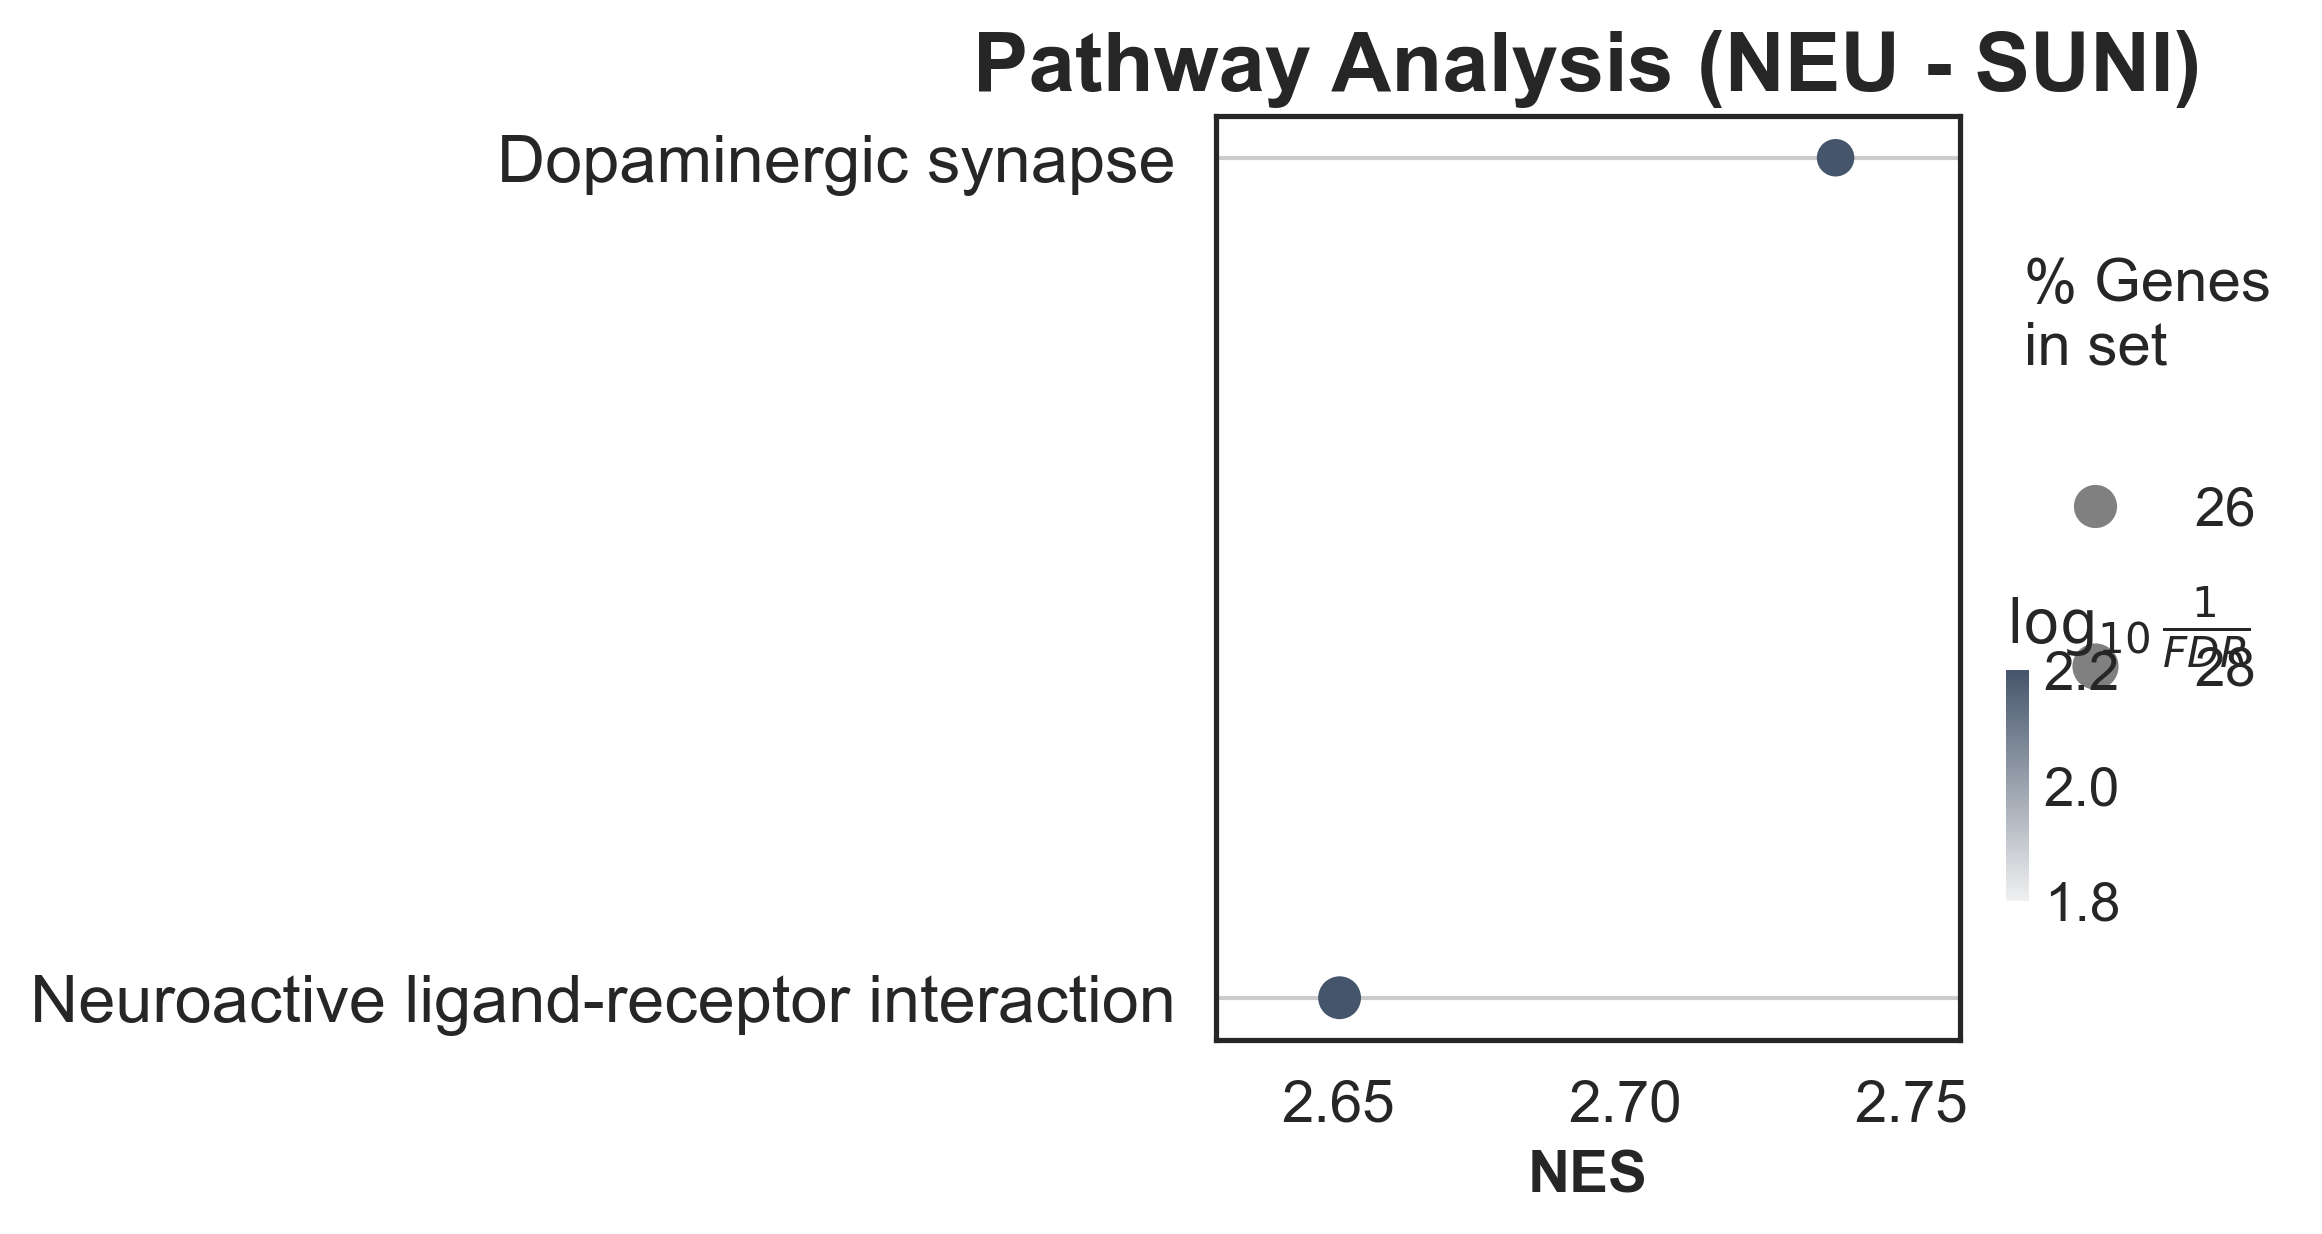

In [286]:
term = enr.res2d.copy()
term.Term = term.Term.str.replace("KEGG_2021_Human__","")
ax = gp.dotplot(term,
             # column="-log(Qvalue)",
                column="FDR q-val",
             title='Pathway Analysis (%s - %s)'%(ct,br),
             cmap=cmap,
              top_term=20,
             size=6, # adjust dot size
             figsize=(4,4), cutoff=0.05, show_ring=False)
plt.savefig("outdir/pathway_deconvoluted_%s_%s.svg"%(br,ct))

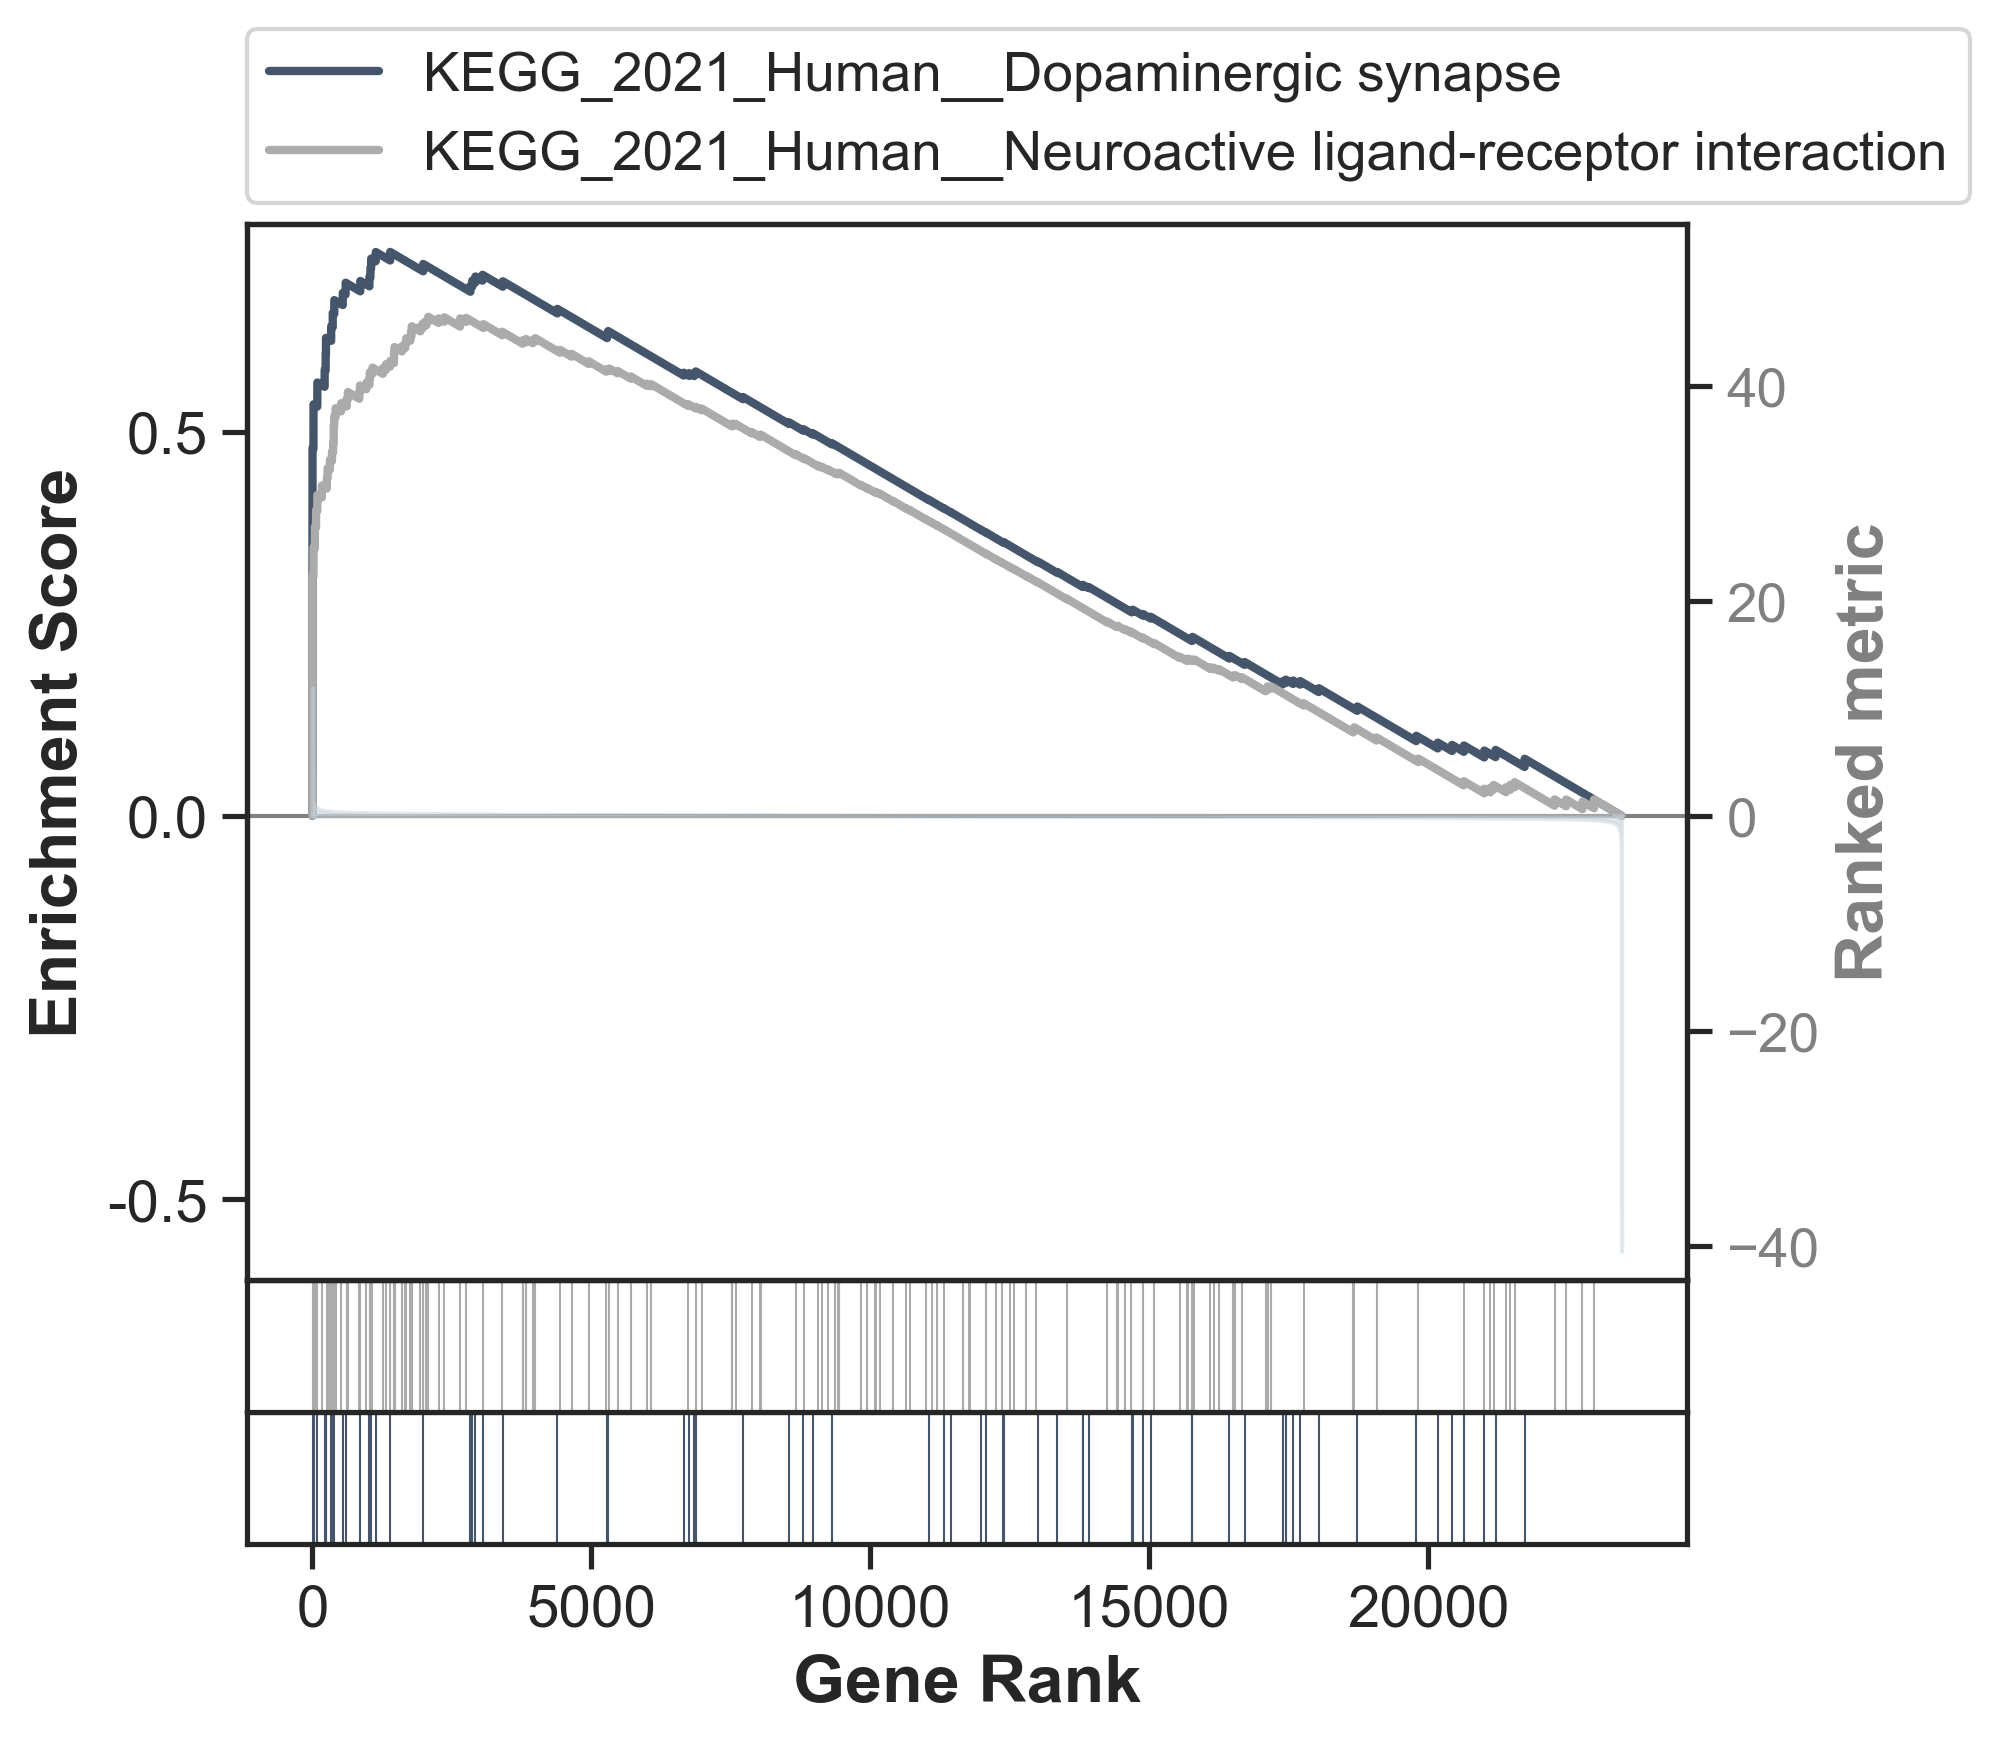

In [305]:
enr.res2d = enr.res2d.sort_values("FDR q-val")

terms = enr.res2d.Term
axs = enr.plot(terms= enr.res2d.Term[:2], figsize=(6,4), 
               colors=["#45556B", "#ABABAB"],
            ) # v1.0.5
plt.savefig("outdir/enrichment_neu_3.svg")